### 전처리 1. 파일 불러오기

In [1]:
import flowkit as fk
import os

# 지정된 경로의 .fcs파일을 읽어온다.
def load_fcs_file(file_path):
    if not os.path.exists(file_path):
        print(f" 오류 : 경로에 파일이 존재하지 않습니다. -> {file_path}")
        return None
    try :
        sample = fk.Sample(file_path, ignore_offset_error=True)
        print(f"성공적으로 파일을 불러왔습니다. {sample.id}")
        print(f"채널 수 : {len(sample.pnn_labels)}개")
        print(f"수집된 세포 수 : {sample.event_count:,}개")
        return sample
    except Exception as e:
        print(f"파일을 불러오는 중 오류가 발생했습니다. {e}")
        return None

fcs_dir = './7867212_sample_data/FL'
fcs_files = [f for f in os.listdir(fcs_dir) if f.endswith('.fcs')]
all_sample_data = []

for f_name in fcs_files:
    full_path = os.path.join(fcs_dir, f_name)
    loaded_sample = load_fcs_file(full_path)
    if loaded_sample is not None:
        all_sample_data.append(loaded_sample)

print(f"\n [[완료]] 총 {len(all_sample_data)}개의 샘플을 정상적으로 저장했습니다.")

성공적으로 파일을 불러왔습니다. FL Mds1 12 07 2024_FL 2 12 07 2024_007.fcs
채널 수 : 20개
수집된 세포 수 : 772,384개
성공적으로 파일을 불러왔습니다. FL Mds1 12 07 2024_FL 3 12 07 2024_008.fcs
채널 수 : 20개
수집된 세포 수 : 663,008개
성공적으로 파일을 불러왔습니다. FL Mds1 12 07 2024_FL 4 12 07 2024_009.fcs
채널 수 : 20개
수집된 세포 수 : 679,584개
성공적으로 파일을 불러왔습니다. FL Mds1 12 07 2024_FL 6 12 07 2024_010.fcs
채널 수 : 20개
수집된 세포 수 : 768,880개
성공적으로 파일을 불러왔습니다. FL Mds1 17 07 2024_FL1_008.fcs
채널 수 : 20개
수집된 세포 수 : 554,752개
성공적으로 파일을 불러왔습니다. FL Mds1 17 07 2024_FL2_009.fcs
채널 수 : 20개
수집된 세포 수 : 1,000,000개

 [[완료]] 총 6개의 샘플을 정상적으로 저장했습니다.


### 전처리 2. cell debris 제거 (main population과 분리, cutoff)

In [31]:
# cutoff - sample 개별로 처리  (단순 cutoff)

import numpy as np

def remove_cell_debris(sample, FSC_A='FSC-A', SSC_A='SSC-A', cutoff_percent=15):
    events = sample.get_events(source='raw')
    fsc_idx = sample.pnn_labels.index(FSC_A)
    ssc_idx = sample.pnn_labels.index(SSC_A)

    fsc_data = events[:, fsc_idx]
    ssc_data = events[:, ssc_idx]

    fsc_cutoff = np.percentile(fsc_data, cutoff_percent)
    ssc_cutoff = np.percentile(ssc_data, cutoff_percent)

    clean_filter = (fsc_data > fsc_cutoff) & (ssc_data > ssc_cutoff)

    clean_main_population = events[clean_filter]

    #결과 요약
    print(f"\n[ {sample.id} ] 정리 리포트")
    print(f" 적용된 cutoff 기준선 : {FSC_A}: 하위{fsc_cutoff:.0f}이하 버림 \n {SSC_A}: 하위 {ssc_cutoff:.0f}이하 버림")
    print(f"original events : {len(events):,}개")
    print(f"main population : {len(clean_main_population):,}개")

    return clean_main_population

# if len(all_sample_data) > 0:
#     test_sample = all_sample_data[0]

#     cleaned_data_array = remove_cell_debris(test_sample, FSC_A='FSC-A', SSC_A='SSC-A', cutoff_percentile=15)

In [32]:
# cutoff - sample 파일 전체 처리 후 동일 적용 (단순 cutoff)

sample_size = 100000   #랜덤하게 뽑을 세포 수
debris_percentile = 15 #하위 15%을 debris로 판단
FSC_A = 'FSC-A'
SSC_A = 'SSC-A'

# [Step 1] 전체 파일에서 데이터를 일부 모아 '통합 학습모델'용 데이터 구성
print("[[Step1]] \n >>> 모든 샘플에서 데이터를 모아 [통합 기준점]을 학습합니다.")
all_events_list = []

for sample in all_sample_data:
    events = sample.get_events(source='raw')

    fsc_idx = sample.pnn_labels.index(FSC_A)
    ssc_idx = sample.pnn_labels.index(SSC_A)

    # 해당 파일의 세포 수가 적으면 에러가 나지 않도록 조정
    actual_size = min(len(events), sample_size)

    idx = np.random.choice(len(events), actual_size, replace=False)

    sub_data = events[idx][:, [fsc_idx, ssc_idx]]
    all_events_list.append(sub_data)

total_data = np.vstack(all_events_list)


# [Step 2] 통합 데이터에서 cutoff 계산
global_fsc_cutoff = np.percentile(total_data[:, 0], debris_percentile)
global_ssc_cutoff = np.percentile(total_data[:, 1], debris_percentile)

print(f"cutoff 기준 : {FSC_A}가 {global_fsc_cutoff:.0f}보다 작거나 {SSC_A}가 {global_ssc_cutoff:.0f}보다 작으면 cut-off")


# [Step 3] 파일 전체에 cutoff 기준 적용
global_cleaned_samples = []

for sample in all_sample_data:
    events = sample.get_events(source='raw')

    fsc_idx = sample.pnn_labels.index(FSC_A)
    ssc_idx = sample.pnn_labels.index(SSC_A)

    fsc_data = events[:, fsc_idx]
    ssc_data = events[:, ssc_idx]

    clean_mask = (fsc_data > global_fsc_cutoff) & (ssc_data > global_ssc_cutoff)
    cleaned_events = events[clean_mask] # cell debris 걸러진 데이터

    global_cleaned_samples.append({
        'id': sample.id,
        'clean_events': cleaned_events,
        'original_count': len(events),
        'clean_count': len(cleaned_events)
    })

    print(f" [적용 완료>>> \n 샘플명 : {sample.id}>] \n 원본 {len(events):,}개에서 {len(cleaned_events):,} 남음")

print("모든 파일에 Cell Debris 제거 전처리가 끝났습니다.")


[[Step1]] 
 >>> 모든 샘플에서 데이터를 모아 [통합 기준점]을 학습합니다.
cutoff 기준 : FSC-A가 23060보다 작거나 SSC-A가 6229보다 작으면 cut-off
 [적용 완료>>> 
 샘플명 : FL Mds1 12 07 2024_FL 2 12 07 2024_007.fcs>] 
 원본 772,384개에서 607,642 남음
 [적용 완료>>> 
 샘플명 : FL Mds1 12 07 2024_FL 3 12 07 2024_008.fcs>] 
 원본 663,008개에서 514,641 남음
 [적용 완료>>> 
 샘플명 : FL Mds1 12 07 2024_FL 4 12 07 2024_009.fcs>] 
 원본 679,584개에서 535,040 남음
 [적용 완료>>> 
 샘플명 : FL Mds1 12 07 2024_FL 6 12 07 2024_010.fcs>] 
 원본 768,880개에서 613,670 남음
 [적용 완료>>> 
 샘플명 : FL Mds1 17 07 2024_FL1_008.fcs>] 
 원본 554,752개에서 408,811 남음
 [적용 완료>>> 
 샘플명 : FL Mds1 17 07 2024_FL2_009.fcs>] 
 원본 1,000,000개에서 717,084 남음
모든 파일에 Cell Debris 제거 전처리가 끝났습니다.


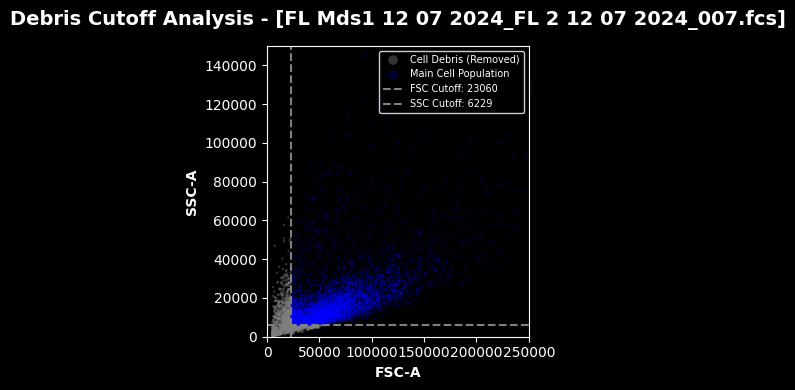

In [33]:
# 산점도로 확인 (그냥 복붙..)

import matplotlib.pyplot as plt

def plot_cutoff_scatter(sample, fsc_cutoff, ssc_cutoff, channel_x='FSC-A', channel_y='SSC-A', sample_size=10000):
    events = sample.get_events(source='raw')
    
    # 점이 수백만 개 찍히면 컴퓨터가 멈추고 뭉쳐서 보이지 않으므로 
    # 랜덤 1만 개만 추출하여 쾌적하게 그래프를 그립니다.
    actual_size = min(len(events), sample_size)
    idx = np.random.choice(len(events), actual_size, replace=False)
    
    fsc_idx = sample.pnn_labels.index(channel_x)
    ssc_idx = sample.pnn_labels.index(channel_y)
    
    fsc_data = events[idx, fsc_idx]
    ssc_data = events[idx, ssc_idx]
    
    # 깔끔한 비율의 캔버스(도화지) 준비
    plt.figure(figsize=(4, 4))
    
    # 점들을 분리하기 위한 조건(마스크) 설정
    clean_mask = (fsc_data > fsc_cutoff) & (ssc_data > ssc_cutoff)
    
    # ----------------------------------------------------
    # 1. 컷오프를 통과하지 못해 잘려나갈 파편(Debris) - 투명한 다홍색(Crimson)
    plt.scatter(fsc_data[~clean_mask], ssc_data[~clean_mask], 
                s=3, c='gray', alpha=0.4, label='Cell Debris (Removed)', edgecolors='none')
    
    # 2. 컷오프를 통과하여 분석할 진짜 세포(Main Pop) - 투명한 스카이블루(Dodgerblue)
    plt.scatter(fsc_data[clean_mask], ssc_data[clean_mask], 
                s=3, c='blue', alpha=0.2, label='Main Cell Population', edgecolors='none')
    
    # ----------------------------------------------------
    # 3. 가위로 잘라내는 기준점(Cutoff)을 가로/세로 검은 점선으로 긋기
    plt.axvline(x=fsc_cutoff, color='gray', linestyle='--', linewidth=1.5, 
                label=f'FSC Cutoff: {fsc_cutoff:.0f}')
    
    plt.axhline(y=ssc_cutoff, color='gray', linestyle='--', linewidth=1.5, 
                label=f'SSC Cutoff: {ssc_cutoff:.0f}')
    
    # ----------------------------------------------------
    # 그림 설명과 디자인(데코레이션) 추가
    plt.title(f"Debris Cutoff Analysis - [{sample.id}]", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(channel_x, fontsize=10, fontweight='bold')
    plt.ylabel(channel_y, fontsize=10, fontweight='bold')
    
    # 보통 유세포 분석값 범위는 최대 20~25만 정도이므로,
    # 한눈에 보기 좋게 그래프 좌측 하단의 노이즈 밀집 구역에 포커스를 맞춥니다.
    plt.xlim(0, 250000)
    plt.ylim(0, 150000)

    
    # 오른쪽 상단에 범례 위치 (점 크기를 키워서 보여주기: markerscale)
    plt.legend(markerscale=4, fontsize=7, loc='upper right', frameon=True, shadow=True)
    
    # 디자인 최적화 후 그리기!
    plt.tight_layout()
    plt.show()

if len(all_sample_data) > 0:
    plot_cutoff_scatter(all_sample_data[0], global_fsc_cutoff, global_ssc_cutoff)




### GMM(Gaussian Mixture Model) 가우시안 분포로 main-population 잡기 - XX 분리 못함

In [11]:
# sample 파일 전체 처리 후 동일 적용 (GMM 적용)
import numpy as np
from sklearn.mixture import GaussianMixture

sample_size = 100000
FSC_A = 'FSC-A'
SSC_A = 'SSC-A'

#[Step 1] 전체 파일에서 데이터를 모아 GMM 학습모델 구성
print("[[Step 1]] \n >>> 각 샘플에서 데이터를 모아 통합기준점 학습합니다...")
all_events_list = []

for sample in all_sample_data:
    events = sample.get_events(source='raw')

    fsc_idx = sample.pnn_labels.index(FSC_A)
    ssc_idx = sample.pnn_labels.index(SSC_A)

    actual_size = min(len(events), sample_size) #에러 방지용
    idx = np.random.choice(len(events), actual_size, replace=False)

    sub_data = events[idx][:, [fsc_idx, ssc_idx]]
    all_events_list.append(sub_data)

total_data = np.vstack(all_events_list)

# GMM 학습시키기
# 최적의 군집개수를 스스로 선택하게 만드는 방식
lowest_BIC = np.infty
best_GMM = None
best_K = 2

for k in range(2, 3):
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(total_data)

    bic_score = gmm.bic(total_data) # 학습된 모델의 BIC점수 계산, 낮을수록 최적화
    print(f"  - 군집 수가 {k}개일 때 BIC 점수 : {bic_score:.0f}")

    if bic_score < lowest_BIC:
        lowest_BIC = bic_score
        best_GMM = gmm
        best_K = k

print(f"\n >>> 탐색 완료! 최적의 군집 개수는 [{best_K}개] 입니다.")

cluster_means = best_GMM.means_
debris_cluster_idx = np.argmin(cluster_means.sum(axis=1))

print(f" >>> (군집 {debris_cluster_idx}번이 Debris로 판별되었습니다.)")

[[Step 1]] 
 >>> 각 샘플에서 데이터를 모아 통합기준점 학습합니다...
  - 군집 수가 2개일 때 BIC 점수 : 26510321

 >>> 탐색 완료! 최적의 군집 개수는 [2개] 입니다.
 >>> (군집 0번이 Debris로 판별되었습니다.)


C:\Users\301-22\AppData\Local\Temp\ipykernel_9908\1086791550.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('tab10')(k)
C:\Users\301-22\AppData\Local\Temp\ipykernel_9908\1086791550.py:37: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


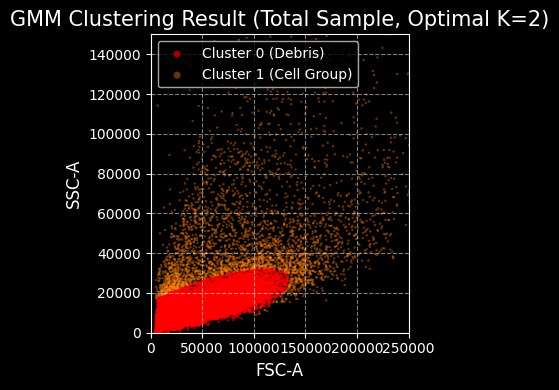

In [18]:
# GMM 테스트
import matplotlib.pyplot as plt
import numpy as np

# 1. 시각화를 위해 일부 데이터만 샘플링 (속도 향상 및 과밀화 방지)
viz_sample_size = 30000
viz_idx = np.random.choice(total_data.shape[0], viz_sample_size, replace=False)
viz_data = total_data[viz_idx]

# 2. 샘플링된 데이터에 대해 학습된 GMM 모델로 예측 (라벨 부여)
viz_predictions = best_GMM.predict(viz_data)

# 3. 그래프 그리기
plt.figure(figsize=(4, 4))

# --- 핵심: 군집별로 다른 색으로 점 찍기 ---
# 모든 군집 수(best_k)만큼 반복하면서 점을 그립니다.
for k in range(best_K):
    # k번째 군집에 속하는 데이터만 마스킹
    cluster_mask = (viz_predictions == k)

    # 해당 군집의 데이터 추출
    cluster_data = viz_data[cluster_mask]

    # 군집의 정체성에 따라 색상 및 범례 이름 설정
    if k == debris_cluster_idx:
        color = 'red' # Debris는 빨간색으로 눈에 띄게!
        label_name = f'Cluster {k} (Debris)'
        alpha = 0.6   # Debris는 약간 투명하게
    else:
        # 정상 세포들은 색깔을 알아서 다양하게 (cmap 활용)
        color = plt.cm.get_cmap('tab10')(k)
        label_name = f'Cluster {k} (Cell Group)'
        alpha = 0.4   # 정상 세포는 더 투명하게 겹쳐 보이도록

    # Scatter Plot 그리기
    plt.scatter(
        cluster_data[:, 0], # FSC-A
        cluster_data[:, 1], # SSC-A
        c=color,
        label=label_name,
        s=3,        # 점 크기 (작게)
        alpha=alpha, # 투명도
        edgecolors='none' # 테두리 없음
    )

# 4. 그래프 꾸미기 (가독성 향상)
plt.title(f'GMM Clustering Result (Total Sample, Optimal K={best_K})', fontsize=15)
plt.xlabel(FSC_A, fontsize=12)
plt.ylabel(SSC_A, fontsize=12)

# 범례 크기 및 위치 조정
plt.legend(markerscale=3, fontsize=10, loc='best')

# 그리드 추가
plt.grid(True, linestyle='--', alpha=0.5)

# 축 범위 자동 조정 (데이터가 몰려있는 곳 위주로)
plt.xlim(0, 250000)
plt.ylim(0, 150000)

plt.tight_layout()
plt.show()

### DBSCAN 기반 main-population 잡기

In [22]:
# DBSCAN 기반
import numpy as np
from sklearn.cluster import DBSCAN

sample_size = 100000
FSC_A = 'FSC-A'
SSC_A = 'SSC-A'

print("[[Step 1]] \n >>> DBSCAN 모델로 최적의 군집을 스스로 찾고 학습합니다...")
all_events_list = []

for sample in all_sample_data:
    events = sample.get_events(source='raw')

    fsc_idx = sample.pnn_labels.index(FSC_A)
    ssc_idx = sample.pnn_labels.index(SSC_A)

    actual_size = min(len(events), sample_size) #에러 방지용
    idx = np.random.choice(len(events), actual_size, replace=False)

    sub_data = events[idx][:, [fsc_idx, ssc_idx]]
    all_events_list.append(sub_data)

total_data = np.vstack(all_events_list)

# [Step 1] DBSCAN기반 모델 학습
dbscan = DBSCAN(eps=5000, min_samples=100)
dbscan_labels = dbscan.fit_predict(total_data)

cluster_means = dbscan.components_
debris_cluster_idx = np.argmin(cluster_means.sum(axis=1))

print(f" >>> 학습 완료! (알고리즘이 {debris_cluster_idx}번 군집을 Debris로 판별했습니다.)\n")

# [Step 2] 학습 기준을 전체 파일에 적용


[[Step 1]] 
 >>> DBSCAN 모델로 최적의 군집을 스스로 찾고 학습합니다...


MemoryError: 

### 전처리 3. singlet 구역 잡기

In [50]:
from sklearn.linear_model import RANSACRegressor

singlet_FSC_H = 'FSC-H'
singlet_FSC_A = 'FSC-A'

# 지정한 값으로 cutoff 하는방법 -> 기계또는 샘플링 방법에 따라 달라질 수 있음
# SINGLET_DIFF_LOWER = -15000  
# SINGLET_DIFF_UPPER = 30000


# [Step 1] cell debris 제거된 데이터에서 siglet 예측하기
print("1단계 : cell debris가 제거된 데이터에서 추세선 학습합니다...")
cleaned_events_list = []

for sample_info in global_cleaned_samples:
    clean_events = sample_info['clean_events']
    actual_size = min(len(events), sample_size)
    
    idx = np.random.choice(len(clean_events), actual_size, replace=False)
    
    sample_obj = all_sample_data[0] 
    fscH_idx = sample_obj.pnn_labels.index(singlet_FSC_H)
    fscA_idx = sample_obj.pnn_labels.index(singlet_FSC_A)
    
    sub_data = clean_events[idx][:, [fscH_idx, fscA_idx]]
    cleaned_events_list.append(sub_data)

total_clean_data = np.vstack(cleaned_events_list)

global_ransac = RANSACRegressor(random_state=42)
global_ransac.fit(total_clean_data[:, 0].reshape(-1, 1), total_clean_data[:, 1])

global_y_pred = global_ransac.predict(total_clean_data[:, 0].reshape(-1, 1))
global_diff_errors = total_clean_data[:, 1] - global_y_pred
mean_err = np.mean(global_diff_errors)      # 오차의 평균
std_err = np.std(global_diff_errors)        # 오차의 표준편차
SINGLET_DIFF_LOWER = mean_err - (1.5 * std_err)
SINGLET_DIFF_UPPER = mean_err + (1.5 * std_err)


# [Step 2] 모든 파일에 일괄 적용하여 doublet 제거
print("2단계 : 완성된 추세선 모델을 전 파일에 적용합니다...")

final_singlet_samples = []

for sample_info in global_cleaned_samples:
    clean_events = sample_info['clean_events']
    
    sample_obj = all_sample_data[0]
    fscH_idx = sample_obj.pnn_labels.index(singlet_FSC_H)
    fscA_idx = sample_obj.pnn_labels.index(singlet_FSC_A)

    fscH_data = clean_events[:, fscH_idx].reshape(-1, 1)
    fscA_data = clean_events[:, fscA_idx]

    y_pred = global_ransac.predict(fscH_data)
    diff = fscA_data - y_pred

    singlet_mask = (diff > SINGLET_DIFF_LOWER) & (diff < SINGLET_DIFF_UPPER)
    singlets = clean_events[singlet_mask]  # singlelet 순수데이터

    final_singlet_samples.append({
        'id': sample_info['id'],           
        'singlets': singlets,              
        'singlet_count': len(singlets),    
        'clean_count': sample_info['clean_count']  
    })

    print(f"{sample_info['id']}] 투입: {len(clean_events):,} -> Singlet: {len(singlets):,}개")

print("singlet 구역 확인 완료")6

1단계 : cell debris가 제거된 데이터에서 추세선 학습합니다...
2단계 : 완성된 추세선 모델을 전 파일에 적용합니다...
FL Mds1 12 07 2024_FL 2 12 07 2024_007.fcs] 투입: 607,260 -> Singlet: 559,658개
FL Mds1 12 07 2024_FL 3 12 07 2024_008.fcs] 투입: 514,393 -> Singlet: 487,035개
FL Mds1 12 07 2024_FL 4 12 07 2024_009.fcs] 투입: 534,688 -> Singlet: 496,784개
FL Mds1 12 07 2024_FL 6 12 07 2024_010.fcs] 투입: 613,347 -> Singlet: 566,888개
FL Mds1 17 07 2024_FL1_008.fcs] 투입: 408,396 -> Singlet: 386,986개
FL Mds1 17 07 2024_FL2_009.fcs] 투입: 716,475 -> Singlet: 633,323개
singlet 구역 확인 완료


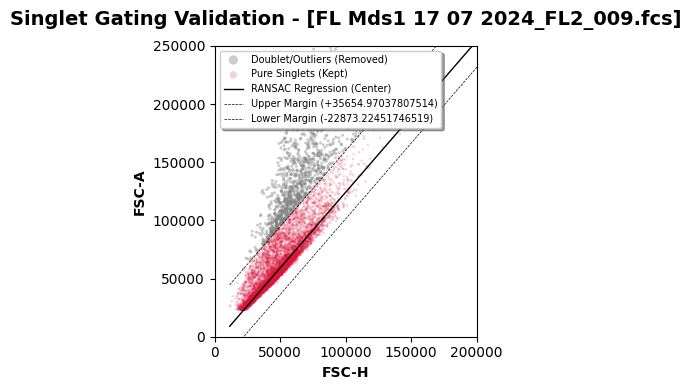

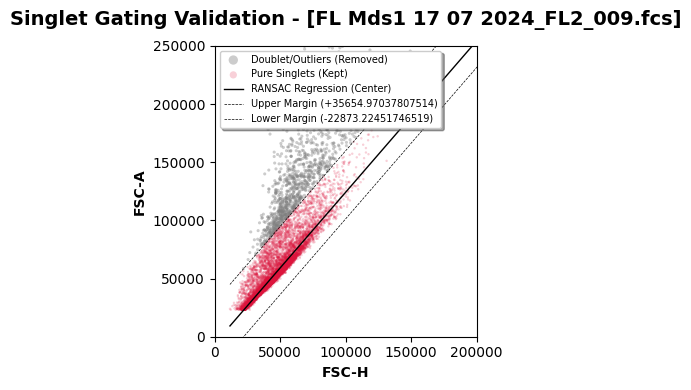

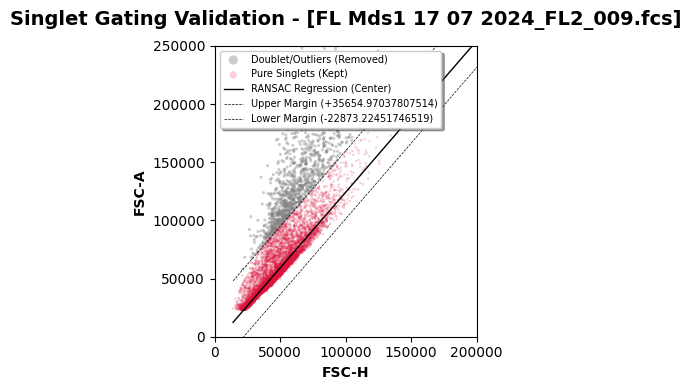

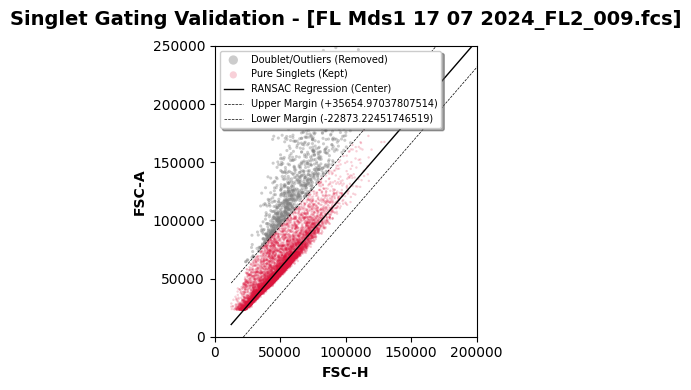

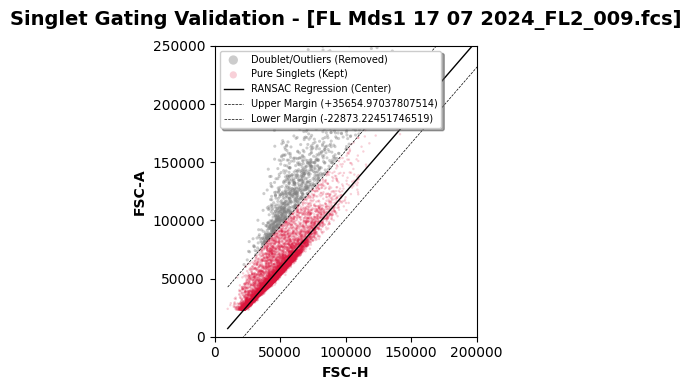

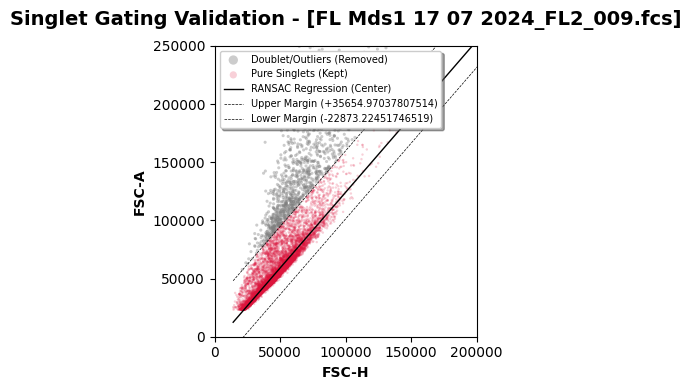

In [59]:
def plot_singlet_gating(sample_info, ransac_model, diff_lower, diff_upper, channel_x='FSC-H', channel_y='FSC-A', sample_size=10000):
    """
    RANSAC 회귀선을 중앙에 긋고 위아래 허용 범위 마지노선(점선)을 그려,
    살아남은 Singlet(파란색)과 거름망을 통과하지 못한 더블릿 이상치(빨간색)를 시각화합니다.
    """
    # 1. 이전 단계에서 1차로 걸러뒀던 "잔해가 없는 파일"을 가져옵니다.
    clean_events = sample_info['clean_events']
    
    # 너무 많은 점이 겹쳐서 느려지지 않게 쾌적한 1만 개 스푼만 덜어냅니다.
    actual_size = min(len(clean_events), sample_size)
    idx = np.random.choice(len(clean_events), actual_size, replace=False)
    
    # X, Y 채널 찾기 (채널 이름 순서는 샘플 모두 공통이므로 앞전 객체를 사용합니다)
    sample_obj = all_sample_data[0] 
    fscH_idx = sample_obj.pnn_labels.index(channel_x)
    fscA_idx = sample_obj.pnn_labels.index(channel_y)
    
    fscH_data = clean_events[idx, fscH_idx]
    fscA_data = clean_events[idx, fscA_idx]
    
    # 2. 마스크를 씌우기 위해 회귀선 오차를 여기서 다시 계산해봅니다.
    fscH_reshaped = fscH_data.reshape(-1, 1)
    y_pred = ransac_model.predict(fscH_reshaped)
    diff = fscA_data - y_pred
    
    # 위아래 허용 폭(-15000 ~ +30000) 안의 녀석들만 남긴 진정한 단일 세포
    singlet_mask = (diff > diff_lower) & (diff < diff_upper)
    
    # ===============================
    # 도화지 준비 완료!
    plt.figure(figsize=(4, 4))
    
    # 3. 데이터 점 찍기
    # 대각선 레일을 크게 이탈하여 잘려 나갈 '더블릿/이상치'
    plt.scatter(fscH_data[~singlet_mask], fscA_data[~singlet_mask], 
                s=5, c='gray', alpha=0.4, edgecolors='none', label='Doublet/Outliers (Removed)')
    
    # 중앙의 뚜렷한 대각선 레일을 따라 주루룩 모인 '진짜 단일 세포집단' (투명한 다홍색)
    plt.scatter(fscH_data[singlet_mask], fscA_data[singlet_mask], 
                s=3, c='crimson', alpha=0.2, edgecolors='none', label='Pure Singlets (Kept)')
    
    # ===============================
    # 4. RANSAC '글로벌 회귀선'과 위/아래 안전 범위(Gate Line) 그리기
    x_range_min, x_range_max = np.min(fscH_data), np.max(fscH_data)
    
    # 그림을 그릴 수직축 범위를 촘촘히 쪼갭니다.
    x_line = np.linspace(x_range_min, x_range_max, 100).reshape(-1, 1)
    y_line_pred = ransac_model.predict(x_line)
    
    # 정중앙 RANSAC 추세선(우주 고속도로 레일) 긋기 - 굵은 검은색 실선
    plt.plot(x_line, y_line_pred, color='black', linewidth=1, label='RANSAC Regression (Center)')
    
    # 위쪽 허용 마지노선 긋기 (점선)
    plt.plot(x_line, y_line_pred + diff_upper, color='black', linestyle='--', linewidth=0.5, 
             label=f'Upper Margin (+{diff_upper})')
    
    # 아래쪽 허용 마지노선 긋기 (점선)
    plt.plot(x_line, y_line_pred + diff_lower, color='black', linestyle='--', linewidth=0.5, 
             label=f'Lower Margin ({diff_lower})')
    
    # ===============================
    # 타이틀 & 축 & 범례 (인테리어 예쁘게 꾸미기)
    plt.title(f"Singlet Gating Validation - [{sample_info['id']}]", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(channel_x, fontsize=10, fontweight='bold')
    plt.ylabel(channel_y, fontsize=10, fontweight='bold')
    
    # 최소 한계를 잘 제어하여 그래프가 빈틈없이 보기 좋게 만듭니다.
    plt.xlim(0, 200000)
    plt.ylim(0, 250000)
    
    # 좌측 상단에 범례 위치 (점 크기를 키워서 보여주기)
    plt.legend(markerscale=3, fontsize=7, loc='upper left', frameon=True, shadow=True)
    
    plt.tight_layout()
    plt.show()
# ================================
# 위에서 만들었던 전처리된 묶음(global_cleaned_samples) 중 0번째 배열을 테스트로 그립니다!
# ================================
# if len(global_cleaned_samples) > 0:
#     plot_singlet_gating(
#         sample_info=global_cleaned_samples[0], 
#         ransac_model=global_ransac, 
#         diff_lower=SINGLET_DIFF_LOWER, 
#         diff_upper=SINGLET_DIFF_UPPER, 
#         channel_x=singlet_FSC_H, 
#         channel_y=singlet_FSC_A
#     )

for sample_infl in final_singlet_samples:
    plot_singlet_gating(
        sample_info=sample_info, 
        ransac_model=global_ransac, 
        diff_lower=SINGLET_DIFF_LOWER, 
        diff_upper=SINGLET_DIFF_UPPER, 
        channel_x=singlet_FSC_H,  # 이전에 지정한 변수명 그대로 사용
        channel_y=singlet_FSC_A
    )


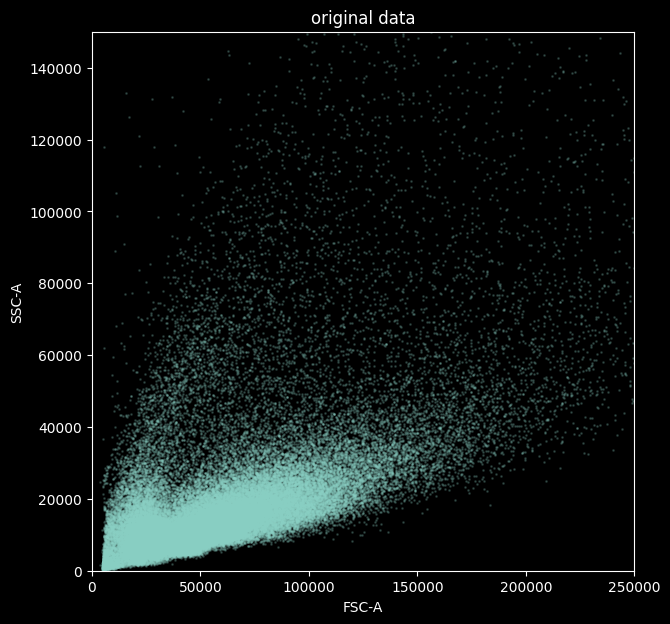

In [39]:
import fcsparser
# .fcs 파일 읽기
path = './7867212_sample_data/FL/FL Mds1 12 07 2024_FL 2 12 07 2024_007.fcs'
meta, data = fcsparser.parse(path)

sampled_data = data.sample(n=100000, random_state=42)

plt.figure(figsize=(7,7))
plt.scatter(sampled_data['FSC-A'], sampled_data['SSC-A'], s=1, alpha=0.2)
plt.title("original data")
plt.xlim(0,250000)
plt.ylim(0,150000)
plt.xlabel("FSC-A")
plt.ylabel("SSC-A")
plt.show()